In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Clustering
from sklearn.cluster import KMeans

# For evaluating optimal clusters
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('heart_attack_youngsters_india.csv')

# Display first 5 rows
df.head()

# Check dataset information
df.info()

# Check dataset information
df.info()

# Check missing values
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       10000 non-null  int64  
 1   Gender                                    10000 non-null  str    
 2   Region                                    10000 non-null  str    
 3   Urban/Rural                               10000 non-null  str    
 4   SES                                       10000 non-null  str    
 5   Smoking Status                            10000 non-null  str    
 6   Alcohol Consumption                       10000 non-null  str    
 7   Diet Type                                 10000 non-null  str    
 8   Physical Activity Level                   10000 non-null  str    
 9   Screen Time (hrs/day)                     10000 non-null  int64  
 10  Sleep Duration (hrs/day)                  1000

Age                                         0
Gender                                      0
Region                                      0
Urban/Rural                                 0
SES                                         0
Smoking Status                              0
Alcohol Consumption                         0
Diet Type                                   0
Physical Activity Level                     0
Screen Time (hrs/day)                       0
Sleep Duration (hrs/day)                    0
Family History of Heart Disease             0
Diabetes                                    0
Hypertension                                0
Cholesterol Levels (mg/dL)                  0
BMI (kg/m²)                                 0
Stress Level                                0
Blood Pressure (systolic/diastolic mmHg)    0
Resting Heart Rate (bpm)                    0
ECG Results                                 0
Chest Pain Type                             0
Maximum Heart Rate Achieved       

In [3]:
# Fill numeric missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# For categorical columns, fill with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [4]:
# Convert categorical columns into numbers
label_encoder = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

In [5]:
scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)

# Convert back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled.head()


,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Stress Level,Blood Pressure (systolic/diastolic mmHg),Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood
0,0.658116,0.851829,-0.856088,0.830518,1.080190,-0.894432,2.240201,-0.964917,0.911656,-0.975003,...,-1.339736,1.598445,-0.432710,0.417445,0.436192,0.665560,-0.331293,-0.291598,-1.684605,-0.505931
1,-0.503778,-0.989964,-0.856088,0.830518,-0.253872,0.382051,0.747828,-0.964917,0.911656,1.618837,...,-1.339736,-0.077187,-0.779183,0.417445,0.436192,-1.189871,-0.331293,0.748918,0.512266,-0.505931
2,-0.503778,-0.989964,-0.273557,0.830518,-0.253872,0.382051,0.747828,0.093803,-2.092647,1.618837,...,-0.137100,-0.039382,-0.201728,0.417445,1.328382,0.123203,-0.331293,-0.777172,0.760676,1.976555
3,0.077169,0.851829,-0.856088,0.830518,1.080190,0.382051,-0.744545,1.152522,0.911656,-0.326543,...,1.065535,1.605446,0.953182,0.417445,0.436192,0.808286,-0.331293,1.199809,-1.343042,1.976555
4,-1.084725,-0.989964,1.474037,-1.204068,-0.253872,0.382051,0.747828,1.152522,-0.590496,-0.758849,...,-0.137100,-0.378569,-0.952419,0.417445,-0.455998,1.607549,-0.331293,-0.014127,-0.310590,-0.505931


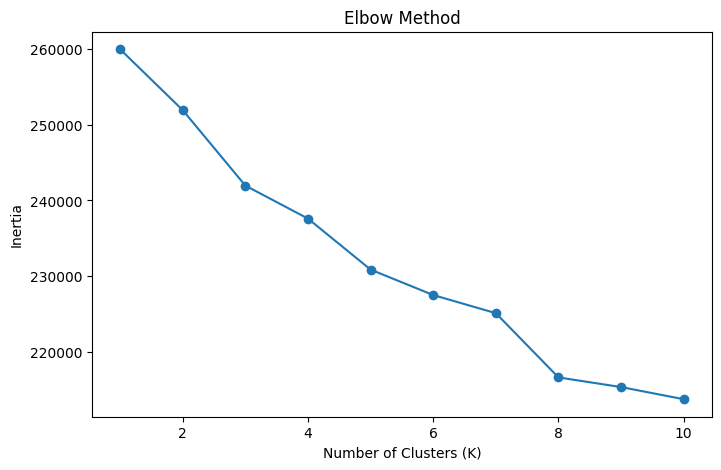

In [6]:
#Finding Optimal Number of Clusters (Elbow Method)

inertia = [] #A measure of how far points are from their group centers

K_range = range(1, 11)  #Try grouping into 1, 2, 3... up to 10 groups

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
#Groups all patients into 3 clusters and labels each patient with their group number (0, 1, or 2)
# Fit model
kmeans.fit(df_scaled)

# Add cluster labels to original dataset
df['Cluster'] = kmeans.labels_

df.head()

,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Blood Pressure (systolic/diastolic mmHg),Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood,Cluster
0,30,1,1,1,2,0,2,0,2,3,...,9517,82,1,2,183,0,94.1,58,0,1
1,24,0,1,1,1,1,1,0,2,15,...,4730,76,1,2,118,0,97.1,341,0,0
2,24,0,2,1,1,1,1,1,0,15,...,4838,86,1,3,164,0,92.7,373,1,2
3,27,1,1,1,2,1,0,2,2,6,...,9537,106,1,2,188,0,98.4,102,1,2
4,21,0,5,0,1,1,1,2,1,4,...,3869,73,1,1,216,0,94.9,235,0,0


In [8]:
#View Cluster Centers
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop('Cluster', axis=1).columns
)

centroids
#This shows the "average patient" for each of the 3 clusters in original units 

,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Stress Level,Blood Pressure (systolic/diastolic mmHg),Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood
0,26.648617,0.528657,2.451516,0.600300,1.194602,0.696435,0.501500,0.924692,1.391036,7.587138,...,1.108464,4936.003999,89.591303,0.852049,1.518494,159.843885,0.098467,94.984055,275.798234,1.526557e-15
1,26.578571,0.543878,2.479082,0.586224,1.170918,0.712755,0.485204,0.872449,1.391327,7.352041,...,1.088776,5039.372449,88.995918,0.852041,1.481122,158.888776,0.094898,94.851378,272.222959,-3.608225e-16
2,26.484789,0.557409,2.513739,0.572130,1.196271,0.701668,0.504416,0.909715,1.400883,7.438175,...,1.154563,4907.765456,89.683513,0.849853,1.518155,159.977429,0.104024,94.899068,275.369480,1.000000e+00


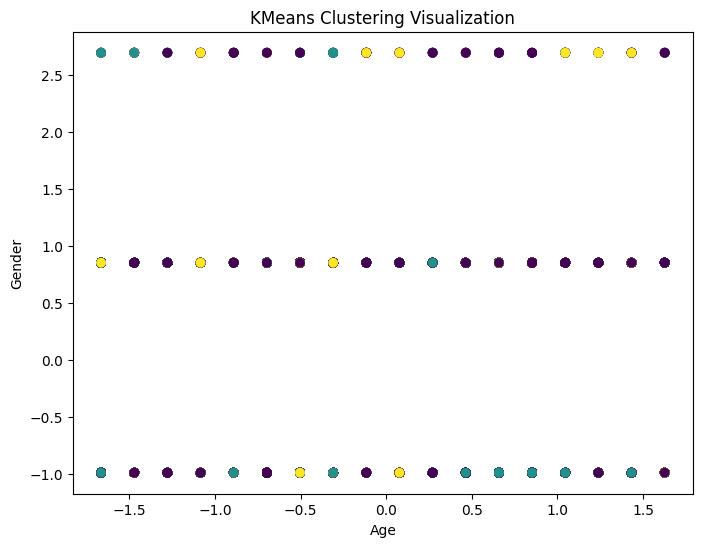

In [9]:
#Visualize Clusters
plt.figure(figsize=(8,6))

plt.scatter(df_scaled.iloc[:,0], df_scaled.iloc[:,1], 
            c=df['Cluster'], cmap='viridis')

plt.title("KMeans Clustering Visualization")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.show()

In [10]:
#Evaluating Quality
score = silhouette_score(df_scaled, kmeans.labels_)

print("Silhouette Score:", score)

#Calculates a score from -1 to 1 that tells us how well separated our clusters are.

Silhouette Score: 0.05063725247821626
